In [12]:
%matplotlib inline

import gym
import matplotlib
import numpy as np
import sys

from collections import defaultdict
if "../" not in sys.path:
  sys.path.append("../") 
from lib.envs.blackjack import BlackjackEnv
from lib import plotting

matplotlib.style.use('ggplot')

In [13]:
env = BlackjackEnv()

In [14]:
def make_epsilon_greedy_policy(Q, epsilon, nA):
    """
    Creates an epsilon-greedy policy based on a given Q-function and epsilon.
    
    Args:
        Q: A dictionary that maps from state -> action-values.
            Each value is a numpy array of length nA (see below)
        epsilon: The probability to select a random action . float between 0 and 1.
        nA: Number of actions in the environment.
    
    Returns:
        A function that takes the observation as an argument and returns
        the probabilities for each action in the form of a numpy array of length nA.
    
    """
    def policy_fn(observation):
        max_action = np.argmax(Q[observation])
        action_probs = np.full(nA, epsilon / nA, dtype=float)
        action_probs[max_action] += (1.0 - epsilon)
        return action_probs
    return policy_fn

In [15]:
def mc_control_epsilon_greedy(env, num_episodes, discount_factor=1.0, epsilon=0.1):
    """
    Monte Carlo Control using Epsilon-Greedy policies.
    Finds an optimal epsilon-greedy policy.
    
    Args:
        env: OpenAI gym environment.
        num_episodes: Number of episodes to sample.
        discount_factor: Gamma discount factor.
        epsilon: Chance the sample a random action. Float betwen 0 and 1.
    
    Returns:
        A tuple (Q, policy).
        Q is a dictionary mapping state -> action values.
        policy is a function that takes an observation as an argument and returns
        action probabilities
    """
    
    # Keeps track of sum and count of returns for each state
    # to calculate an average. We could use an array to save all
    # returns (like in the book) but that's memory inefficient.
    returns_sum = defaultdict(float)
    returns_count = defaultdict(float)
    
    # The final action-value function.
    # A nested dictionary that maps state -> (action -> action-value).
    # 当 key 不存在时，自动创建一个长度为 n 的 0 向量
    # lambda: np.zeros(env.action_space.n) 是一个匿名函数，返回一个长度为 n 的 0 向量
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    
    # The policy we're following
    policy = make_epsilon_greedy_policy(Q, epsilon, env.action_space.n)
    
    for i_episode in range(1, num_episodes + 1):
        # Print out which episo
        # de we're on, useful for debugging.
        if i_episode % 1000 == 0:
            print("\rEpisode {}/{}.".format(i_episode, num_episodes), end="")
            sys.stdout.flush()
        
        # Generate an episode.
        # An episode is an array of (state, action, reward) tuples
        episode = []
        state = env.reset()
        first_sa_indices = {}
        for t in range(100):  # Don't infinite loop while learning
            action_probs = policy(state)
            # choose action according to the probability distribution
            action = np.random.choice(np.arange(len(action_probs)), p=action_probs)
            next_state, reward, done, _ = env.step(action)
            episode.append((state, action, reward))
            # env中这里的state是list或array，是可变类型，dict不接受可变类型作为Key
            # 所以 state用tuple()包裹
            if (tuple(state), action) not in first_sa_indices:
                first_sa_indices[(tuple(state), action)] = t
            if done:
                break
            state = next_state
        
        # calculate returns and update Q for each state-action pair in the episode
        # reverse the episode to calculate returns from the end of the episode
        G = 0.0
        for t in reversed(range(len(episode))):
            s, a, r = episode[t]
            G = r + discount_factor*G
            if first_sa_indices[(tuple(s),a)] ==t:
                returns_sum[(s,a)]+=G
                returns_count[(s,a)]+=1
                Q[s][a] = returns_sum[(s,a)]/returns_count[(s,a)]
    return Q, policy

In [16]:
Q, policy = mc_control_epsilon_greedy(env, num_episodes=500000, epsilon=0.1)

Episode 500000/500000.

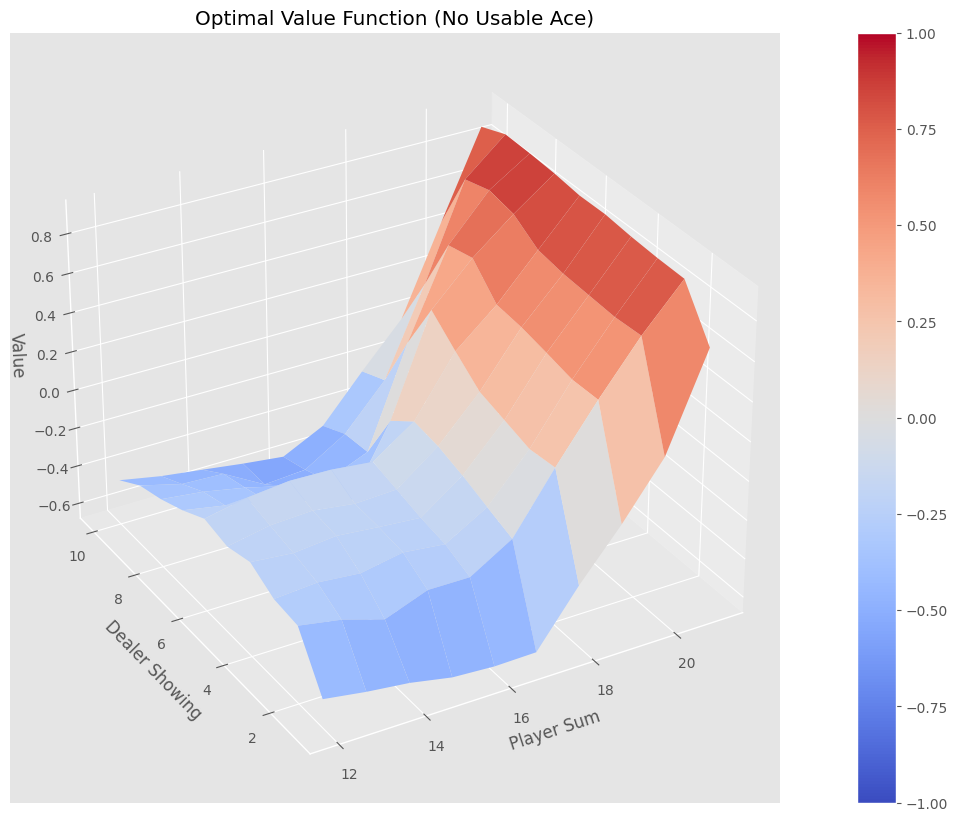

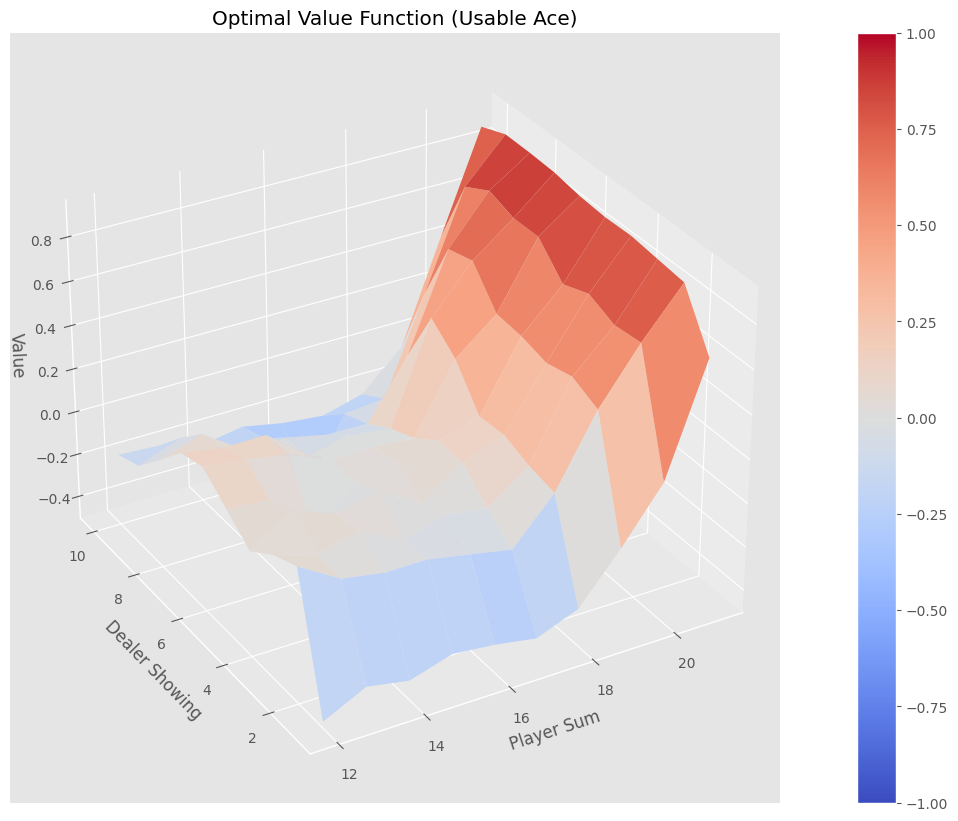

In [17]:
# For plotting: Create value function from action-value function
# by picking the best action at each state
V = defaultdict(float)
for state, actions in Q.items():
    action_value = np.max(actions)
    V[state] = action_value
plotting.plot_value_function(V, title="Optimal Value Function")